In [ ]:
!pip install xgboost imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
data = pd.read_csv("train_transaction.csv")

In [ ]:
print(data.shape)
print(data.head())

(6888, 394)
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN  

In [ ]:
print(data['isFraud'].value_counts())

isFraud
0    6719
1     169
Name: count, dtype: int64


In [ ]:
print(data['isFraud'].value_counts(normalize=True) * 100)

isFraud
0    97.546458
1     2.453542
Name: proportion, dtype: float64


In [ ]:
features = [
    'TransactionAmt',
    'TransactionDT',
    'card1',
    'card2',
    'card3',
    'card5',
    'addr1',
    'addr2'
]

X = data[features]
y = data['isFraud']

In [ ]:
X = X.fillna(X.median())

In [ ]:
print(X.isnull().sum())

TransactionAmt    0
TransactionDT     0
card1             0
card2             0
card3             0
card5             0
addr1             0
addr2             0
dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
isFraud
0    5375
1     135
Name: count, dtype: int64

After SMOTE:
isFraud
0    5375
1    5375
Name: count, dtype: int64


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.7457983193277311


In [ ]:
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    predictions = (xgb_prob >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print(classification_report(y_test, predictions, zero_division=0))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1344
           1       0.12      0.56      0.20        34

    accuracy                           0.89      1378
   macro avg       0.55      0.73      0.57      1378
weighted avg       0.97      0.89      0.92      1378


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1344
           1       0.22      0.53      0.31        34

    accuracy                           0.94      1378
   macro avg       0.60      0.74      0.64      1378
weighted avg       0.97      0.94      0.95      1378


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1344
           1       0.30      0.47      0.37        34

    accuracy                           0.96      1378
   macro avg       0.64      0.72      0.67      1378
weighted avg       0.97   

In [ ]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    predictions = (xgb_prob >= threshold).astype(int)

    f1 = f1_score(y_test, predictions)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.45
Best F1 Score: 0.4375


In [ ]:
xgb_pred = (xgb_prob >= best_threshold).astype(int)

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1344
           1       0.47      0.41      0.44        34

    accuracy                           0.97      1378
   macro avg       0.73      0.70      0.71      1378
weighted avg       0.97      0.97      0.97      1378



In [ ]:
cm = confusion_matrix(y_test, xgb_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1328   16]
 [  20   14]]


In [ ]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

          Feature  Importance
4           card3    0.540985
5           card5    0.132140
0  TransactionAmt    0.083592
3           card2    0.070769
1   TransactionDT    0.061944
6           addr1    0.057173
2           card1    0.053397
7           addr2    0.000000


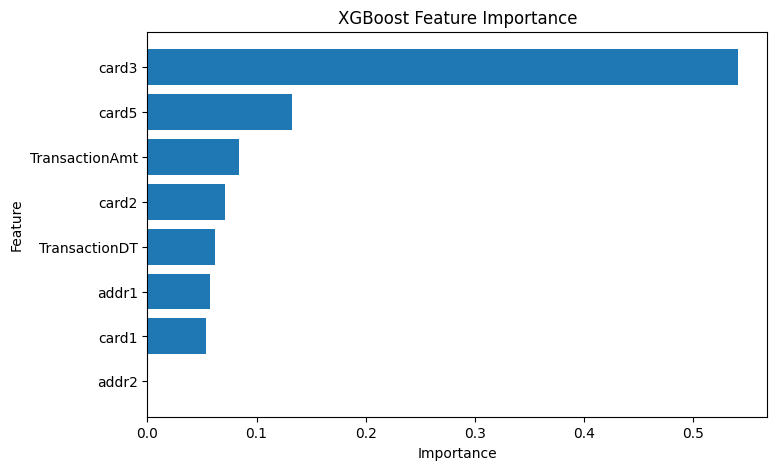

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()